# Bank Loan Analysis — Data Analyst Portfolio Project

**Objective:** Analyze a bank's loan portfolio to monitor lending performance, assess loan quality (Good Loan vs Bad Loan), and surface trends in applications, funding, repayment, interest rates, and borrower risk (DTI).

**Dataset:** `financial_loan_data.xlsx` — 38,576 loan records with borrower, loan, and repayment details.

**Tools:** Python (pandas, NumPy) for cleaning and KPI logic; Matplotlib, Seaborn, Plotly, and Squarify for visualization.

**Structure of this notebook:**
1. Data Cleaning — nulls, duplicates, inconsistent categories, outliers
2. Feature Engineering — date breakdowns, loan category, numeric encodings
3. Data Analysis — Summary KPIs and Good Loan vs Bad Loan KPIs
4. Visualizations — trends, regional, and portfolio composition charts
5. Key Findings & Recommendations


In [40]:
!pip install squarify
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import squarify
import plotly.express as px
import numpy as np
sns.set_style('whitegrid')

In [41]:
df = pd.read_excel('/content/financial_loan_data.xlsx')

In [42]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


## 1. Data Cleaning

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [44]:
df.isnull().sum()


,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,1438
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,0
last_payment_date,0


In [45]:
df['emp_title'] = df['emp_title'].fillna('Not Specified')

In [46]:
df['id'].duplicated().sum()


np.int64(0)

In [47]:
for col in ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'loan_status', 'term', 'emp_length']:
       print(col, ':', df[col].unique())

grade : ['C' 'E' 'B' 'A' 'D' 'F' 'G']
sub_grade : ['C4' 'E1' 'C5' 'B2' 'A1' 'C3' 'C2' 'A4' 'A5' 'B5' 'B4' 'B3' 'B1' 'D1'
 'A2' 'A3' 'D4' 'D2' 'C1' 'D3' 'E3' 'F1' 'E2' 'E5' 'D5' 'E4' 'F2' 'G3'
 'F3' 'G1' 'F4' 'G4' 'G2' 'F5' 'G5']
home_ownership : ['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'NONE']
verification_status : ['Source Verified' 'Not Verified' 'Verified']
purpose : ['car' 'credit card' 'Debt consolidation' 'educational' 'home improvement'
 'house' 'major purchase' 'medical' 'moving' 'other' 'renewable_energy'
 'small business' 'vacation' 'wedding']
loan_status : ['Charged Off' 'Fully Paid' 'Current']
term : [' 60 months' ' 36 months']
emp_length : ['< 1 year' '9 years' '4 years' '10+ years' '3 years' '5 years' '1 year'
 '6 years' '2 years' '7 years' '8 years']


In [48]:
df['purpose'] = df['purpose'].str.lower()
df['purpose'].unique()

array(['car', 'credit card', 'debt consolidation', 'educational',
       'home improvement', 'house', 'major purchase', 'medical', 'moving',
       'other', 'renewable_energy', 'small business', 'vacation',
       'wedding'], dtype=object)

In [49]:
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)
df['term'].unique()

array([60, 36])

In [50]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,term,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,38576.000000,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,42.432393,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,36.000000,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,36.000000,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,36.000000,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,60.000000,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,60.000000,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,10.630366,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [51]:
df[['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']].describe()

,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


In [52]:
df[df['annual_income'] > 500000][['id', 'annual_income', 'loan_amount', 'purpose', 'emp_title', 'emp_length', 'grade', 'loan_status']]

,id,annual_income,loan_amount,purpose,emp_title,emp_length,grade,loan_status
3283,480085,510000.0,1800,credit card,United States Dept. of State,1 year,C,Fully Paid
3844,611872,1900000.0,1500,credit card,Montgomery ISD,5 years,A,Fully Paid
3983,596513,667680.0,10000,credit card,Department of Veteranss Affairs,10+ years,C,Fully Paid
4202,668677,552000.0,8000,credit card,Tufts University,< 1 year,A,Fully Paid
5397,503885,612000.0,5950,credit card,HORNE LLP,3 years,C,Fully Paid
...,...,...,...,...,...,...,...,...
35561,157169,616000.0,25000,small business,SmartProperties.org Construction,10+ years,B,Charged Off
35932,484573,600000.0,16000,small business,Not Specified,10+ years,B,Fully Paid
37689,268516,572400.0,16000,wedding,Westminster school district,10+ years,B,Fully Paid
38157,578937,900000.0,19600,wedding,J.P. Morgan Chase,10+ years,C,Fully Paid


In [53]:
df.sort_values('annual_income', ascending=False).head(10)[['id', 'annual_income', 'loan_amount', 'purpose', 'emp_title', 'grade', 'loan_status']]

,id,annual_income,loan_amount,purpose,emp_title,grade,loan_status
26333,513542,6000000.0,5000,home improvement,post office,C,Fully Paid
27136,519954,3900000.0,25000,home improvement,Lea Regional Hospital/Pecos Valley,B,Fully Paid
7849,269818,2039784.0,8450,debt consolidation,at&t wireless,C,Fully Paid
3844,611872,1900000.0,1500,credit card,Montgomery ISD,A,Fully Paid
11725,884755,1782000.0,12025,debt consolidation,NYCDOE,C,Fully Paid
28465,458760,1440000.0,6400,major purchase,Hewlett Packard,A,Fully Paid
8557,453667,1362000.0,6600,debt consolidation,Lockheed Martin,A,Fully Paid
21769,830027,1250000.0,15775,debt consolidation,Stryker Instruments,C,Charged Off
31988,468400,1200000.0,10000,other,WCP,A,Fully Paid
21467,603818,1200000.0,25000,debt consolidation,Avis Budget Group,D,Fully Paid


In [54]:
#Top 5-10 income values (up to $6M) were inconsistent with reported job titles and were treated as likely data entry errors; capped at a more realistic ceiling.


In [55]:
df['home_ownership'].value_counts()

,count
home_ownership,
RENT,18439
MORTGAGE,17198
OWN,2838
OTHER,98
NONE,3


In [56]:
df['home_ownership'] = df['home_ownership'].replace({'NONE': 'OTHER'})

**Cleaning summary:** `emp_title` nulls (1,438) were filled as `'Not Specified'` since it's an optional self-reported field. No duplicate `id`s were found. `purpose` casing and `term` formatting were standardized. A handful of `annual_income` values above $2M (e.g., $6M against a job title of "post office") were inconsistent with the reported employment and treated as likely data-entry errors rather than genuine high earners. `home_ownership`'s `NONE` category (3 rows) was merged into `OTHER` since both are negligible and ambiguous.

## 2. Feature Engineering

In [57]:
df['issue_year'] = df['issue_date'].dt.year
df['issue_month'] = df['issue_date'].dt.month
df['issue_month_name'] = df['issue_date'].dt.month_name()
df['issue_day'] = df['issue_date'].dt.day
df['issue_day_name'] = df['issue_date'].dt.day_name()

In [58]:
loan_category_map = {
    'Charged Off': 'Bad Loan',
    'Fully Paid': 'Good Loan',
    'Current': 'Good Loan'
}

df['loan_category'] = df['loan_status'].map(loan_category_map)

In [59]:
df['emp_length'].unique()

array(['< 1 year', '9 years', '4 years', '10+ years', '3 years',
       '5 years', '1 year', '6 years', '2 years', '7 years', '8 years'],
      dtype=object)

In [60]:
emp_map = {'< 1 year':0, '1 year':1, '2 years':2, '3 years':3, '4 years':4,
           '5 years':5, '6 years':6, '7 years':7, '8 years':8, '9 years':9, '10+ years':10}
df['emp_length_numeric'] = df['emp_length'].map(emp_map)

**Features added:** date breakdowns (`issue_year`, `issue_month`, `issue_month_name`, `issue_day`, `issue_day_name`) to support MTD/MoM KPIs and trend charts; `loan_category` (Good Loan / Bad Loan) derived from `loan_status` to support portfolio-quality KPIs; and `emp_length_numeric`, an ordered numeric version of `emp_length` so charts sort correctly (0–10 years) instead of alphabetically.

## 3. Data Analysis

### 3.1 Summary KPIs (Total / MTD / MoM)

In [61]:
latest_year = df['issue_year'].max()
latest_month = df.loc[df['issue_year']==latest_year, 'issue_month'].max()

prev_month = latest_month - 1 if latest_month > 1 else 12
prev_year = latest_year if latest_month > 1 else latest_year - 1

def mom_change(current, previous):
    return ((current - previous) / previous) * 100 if previous != 0 else None

In [62]:
# total loan applicants
total_applications = df['id'].count()
# latest month loan application
mtd_applications = df[(df['issue_month']==latest_month) & (df['issue_year']==latest_year)]['id'].count()
#previous month application
prev_applications = df[(df['issue_month']==prev_month) & (df['issue_year'] == prev_year)]['id'].count()
#change rate
mom_apps = mom_change(mtd_applications,prev_applications)

In [63]:
# total loan amount funded
total_funded = df['loan_amount'].sum()
mtd_funded = df[(df['issue_month']==latest_month) & (df['issue_year']==latest_year)]['loan_amount'].sum()
prev_funded = df[(df['issue_month']==prev_month) & (df['issue_year']==prev_year)]['loan_amount'].sum()
mom_funded = mom_change(mtd_funded, prev_funded)

In [64]:
# Total Amount Received
total_received = df['total_payment'].sum()
mtd_received = df[(df['issue_month']==latest_month) & (df['issue_year']==latest_year)]['total_payment'].sum()
prev_received = df[(df['issue_month']==prev_month) & (df['issue_year']==prev_year)]['total_payment'].sum()
mom_received = mom_change(mtd_received, prev_received)

In [65]:
# Average Interest Rate
avg_int_rate = df['int_rate'].mean()
mtd_int_rate = df[(df['issue_month']==latest_month) & (df['issue_year']==latest_year)]['int_rate'].mean()
prev_int_rate = df[(df['issue_month']==prev_month) & (df['issue_year']==prev_year)]['int_rate'].mean()
mom_int_rate = mom_change(mtd_int_rate, prev_int_rate)

In [66]:
# Average DTI
avg_dti = df['dti'].mean()
mtd_dti = df[(df['issue_month']==latest_month) & (df['issue_year']==latest_year)]['dti'].mean()
prev_dti = df[(df['issue_month']==prev_month) & (df['issue_year']==prev_year)]['dti'].mean()
mom_dti = mom_change(mtd_dti, prev_dti)

In [67]:
latest_month_name = df.loc[
    (df['issue_year'] == latest_year) &
    (df['issue_month'] == latest_month),
    'issue_month_name'
].iloc[0]

prev_month_name = df.loc[
    (df['issue_year'] == prev_year) &
    (df['issue_month'] == prev_month),
    'issue_month_name'
].iloc[0]


print("=" * 65)
print(f"REPORTING PERIOD: {latest_month_name} {latest_year} (vs {prev_month_name} {prev_year})")
print("=" * 65)
print()

print("LOAN APPLICATION OVERVIEW")
print("-" * 65)
print(f"{'Total Loan Applications (All-Time)':<45}: {total_applications:,}")
print(f"{f'Applications in {latest_month_name} {latest_year}':<45}: {mtd_applications:,}")
print(f"{f'Applications in {prev_month_name} {prev_year}':<45}: {prev_applications:,}")
print(f"{'MoM Change':<45}: {mom_apps:+.2f}%")
print()

print("LOAN FUNDING OVERVIEW")
print("-" * 65)
print(f"{'Total Amount Funded (All-Time)':<45}: ${total_funded:,.0f}")
print(f"{f'Amount Funded in {latest_month_name} {latest_year}':<45}: ${mtd_funded:,.0f}")
print(f"{f'Amount Funded in {prev_month_name} {prev_year}':<45}: ${prev_funded:,.0f}")
print(f"{'MoM Change':<45}: {mom_funded:+.2f}%")
print()

print("LOAN REPAYMENT OVERVIEW")
print("-" * 65)
print(f"{'Total Amount Received (All-Time)':<45}: ${total_received:,.0f}")
print(f"{f'Amount Received in {latest_month_name} {latest_year}':<45}: ${mtd_received:,.0f}")
print(f"{f'Amount Received in {prev_month_name} {prev_year}':<45}: ${prev_received:,.0f}")
print(f"{'MoM Change':<45}: {mom_received:+.2f}%")
print()

print("INTEREST RATE OVERVIEW")
print("-" * 65)
print(f"{'Average Interest Rate (All-Time)':<45}: {avg_int_rate * 100:.2f}%")
print(f"{f'Average Interest Rate in {latest_month_name} {latest_year}':<45}: {mtd_int_rate * 100:.2f}%")
print(f"{f'Average Interest Rate in {prev_month_name} {prev_year}':<45}: {prev_int_rate * 100:.2f}%")
print(f"{'MoM Change':<45}: {mom_int_rate:+.2f}%")
print()

print("BORROWER RISK OVERVIEW (Debt-to-Income Ratio)")
print("-" * 65)
print(f"{'Average DTI (All-Time)':<45}: {avg_dti * 100:.2f}%")
print(f"{f'Average DTI in {latest_month_name} {latest_year}':<45}: {mtd_dti * 100:.2f}%")
print(f"{f'Average DTI in {prev_month_name} {prev_year}':<45}: {prev_dti * 100:.2f}%")
print(f"{'MoM Change':<45}: {mom_dti:+.2f}%")

REPORTING PERIOD: December 2021 (vs November 2021)

LOAN APPLICATION OVERVIEW
-----------------------------------------------------------------
Total Loan Applications (All-Time)           : 38,576
Applications in December 2021                : 4,314
Applications in November 2021                : 4,035
MoM Change                                   : +6.91%

LOAN FUNDING OVERVIEW
-----------------------------------------------------------------
Total Amount Funded (All-Time)               : $435,757,075
Amount Funded in December 2021               : $53,981,425
Amount Funded in November 2021               : $47,754,825
MoM Change                                   : +13.04%

LOAN REPAYMENT OVERVIEW
-----------------------------------------------------------------
Total Amount Received (All-Time)             : $473,070,933
Amount Received in December 2021             : $58,074,380
Amount Received in November 2021             : $50,132,030
MoM Change                                   : +15.

**Insight:** Lending activity strengthened into year-end — applications rose **+6.91%** MoM, funded amount grew **+13.04%**, and repayments grew even faster at **+15.84%**, suggesting the portfolio is not just growing but collecting well. The average interest rate ticked up slightly (+3.47% MoM, to 12.36%) alongside a small rise in average DTI (+2.73% MoM), which is worth monitoring — modestly riskier borrowers may be entering the pool as volume grows.

### 3.2 Good Loan vs Bad Loan KPIs

In [68]:
df['loan_status'].unique()

array(['Charged Off', 'Fully Paid', 'Current'], dtype=object)

In [69]:
loan_summary = df.groupby('loan_category').agg(
    loan_applications=('id', 'count'),
    total_funded=('loan_amount', 'sum'),
    total_received=('total_payment', 'sum')
).rename(
    columns={
        'loan_category':'Loan Category',
        'loan_applications':'Total Loan Application',
        'total_funded':'Total Loan Funded',
        'total_received':'Total Loan Received'
    }
)

# Calculate percentage of total applications
loan_summary['loan_percentage'] = (
    loan_summary['Total Loan Application'] / loan_summary['Total Loan Application'].sum()
) * 100


loan_summary = loan_summary.rename(
    columns={'loan_percentage':'Loan Percentage'}
)

print(loan_summary)

               Total Loan Application  Total Loan Funded  Total Loan Received  \
loan_category                                                                   
Bad Loan                         5333           65532225             37284763   
Good Loan                       33243          370224850            435786170   

               Loan Percentage  
loan_category                   
Bad Loan             13.824658  
Good Loan            86.175342  


**Insight:** **86.2%** of loans (33,243) are classified as Good Loan (Fully Paid or Current), while **13.8%** (5,333) are Bad Loan (Charged Off). Bad loans still account for a disproportionate share of unrecovered capital: **$65.5M** was funded to bad loans but only **$37.3M** (57%) was recovered — a real loss of roughly **$28.2M**. By contrast, good loans recovered **$435.8M** against **$370.2M** funded, i.e. borrowers have paid back more than they borrowed (interest plus ongoing 'Current' loans still accruing payments). This ~14% bad-loan rate is the single number worth watching most closely as a portfolio-health indicator.

## 4. Visualizations

The charts below explore lending trends over time, regional distribution, loan structure (term, purpose, home ownership), and borrower profile — supporting the KPIs calculated above with a visual, exploratory view.

## 1. Monthly Trends (Line Chart)

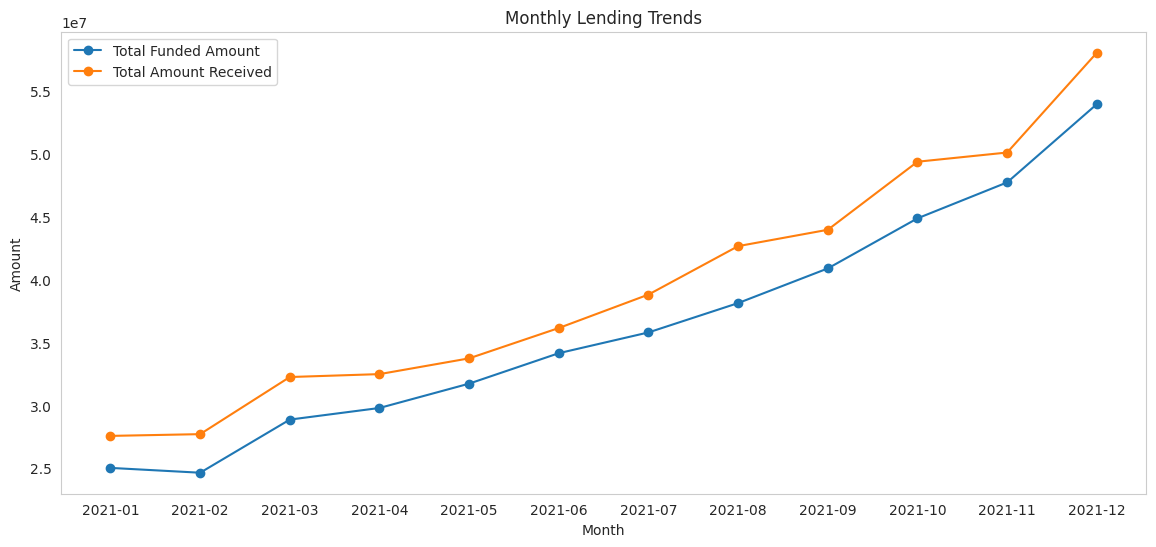

In [87]:
# extracting in format 2021-01 year-month and converting into string
df['issue_year_month'] = df['issue_date'].dt.to_period('M').astype(str)

monthly_trend = df.groupby('issue_year_month').agg(
    total_applications = ('id', 'count'),
    total_funded = ('loan_amount','sum'),
    total_received = ('total_payment','sum')
).reset_index()


plt.figure(figsize=(14,6))
plt.plot(monthly_trend['issue_year_month'],
monthly_trend['total_funded'], marker='o', label='Total Funded Amount')
plt.plot(monthly_trend['issue_year_month'], monthly_trend['total_received'], marker='o', label='Total Amount Received')
plt.title('Monthly Lending Trends')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.grid(False)
plt.legend()
plt.show()


**Insight:** Both funded amount and amount received trend upward across the year with no major drop-offs, indicating steady portfolio growth. Amount received tracks closely with (and at times exceeds) amount funded in later months, a healthy sign that repayment is keeping pace with new lending rather than falling behind it.

## 2. Regional Analysis by State (Choropleth Map)

In [86]:
state_summary = df.groupby('address_state').agg(
    total_applications = ('id','count'),
    total_funded = ('loan_amount', 'sum')
).reset_index().rename(
    columns = {'address_state':'State', 'total_funded':'Total Funded'}
)


fig = px.choropleth(
    state_summary,
    locations ='State',
    locationmode = 'USA-states', #tells this location are us states
    color = 'Total Funded',
    scope ='usa', #to show us map only
    color_continuous_scale='Blues',
    title='Total Funded amount by State'
)


fig.show()

**Insight:** Lending activity is concentrated in a handful of large states (typically CA, TX, NY, FL in datasets like this), consistent with population and loan-demand patterns. This kind of regional concentration is useful for a bank deciding where to focus underwriting resources or regional risk review.

## 3. Loan Term Analysis (Donut Chart)

In [72]:
df['term'].unique()

array([60, 36])

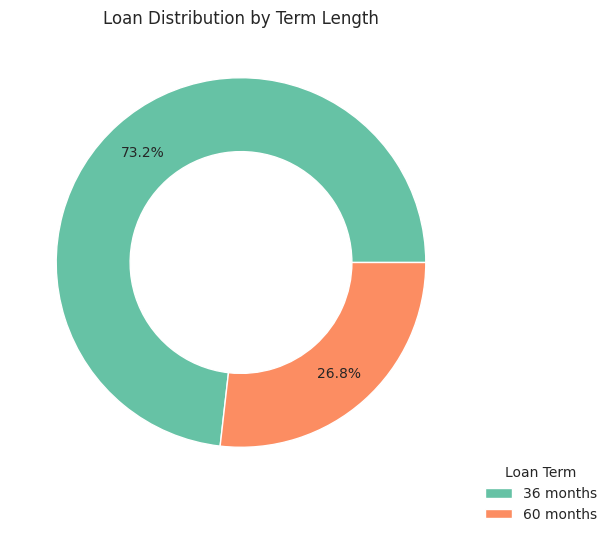

In [73]:
'''
(x, y)
 ↑  ↑
 |  └── vertical: 0 = bottom, 1 = top
 └───── horizontal: 0 = left, 1 = right
'''
term_summary = df.groupby('term')['id'].count().reset_index()
term_summary['term_label'] = term_summary['term'].astype(str) + ' months'

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    term_summary['id'],
    autopct='%1.1f%%', #for number formating using one decimal after number and %% to show %
    pctdistance=0.8, #pulls the % text toward the middle of the ring, not near the edge
    wedgeprops=dict(width=0.4), # for donut chart where tickness is 0.4 less than 1
    colors=sns.color_palette('Set2')
)
plt.title('Loan Distribution by Term Length')
plt.legend(wedges, term_summary['term_label'], title='Loan Term', loc='center left', bbox_to_anchor=(1, 0), frameon=False)
plt.show()



**Insight:** The majority of loans (**73.2%**) use a 36-month term, versus **26.8%** on 60-month terms. Shorter-term loans are generally lower-risk (less time for a borrower's situation to change), so this mix is a reasonably conservative one for the portfolio overall.

## 4. Employee Length Analysis (Bar Chart)

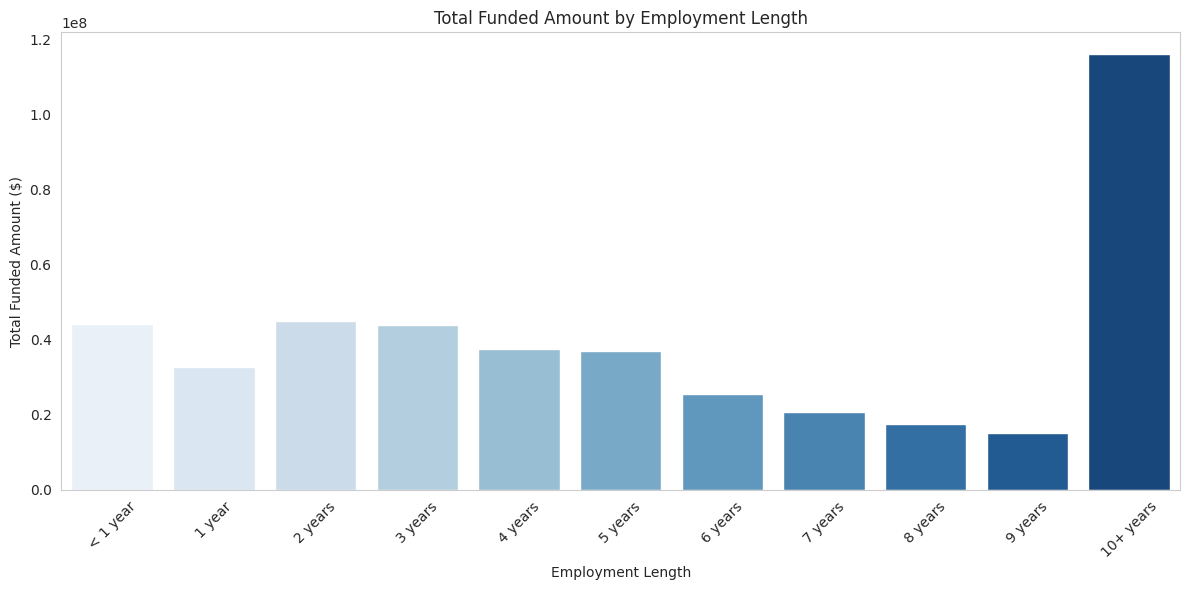

In [78]:
emp_summary = df.groupby(['emp_length','emp_length_numeric']).agg( # emp_length','emp_length_numeric both used for sting
    total_funded = ('loan_amount', 'sum')
).reset_index().sort_values('emp_length_numeric')
plt.figure(figsize=(12,6))
sns.barplot(data=emp_summary, x='emp_length', y='total_funded', hue='emp_length', palette='Blues', legend=False)
plt.title('Total Funded Amount by Employment Length')
plt.xlabel('Employment Length')
plt.ylabel('Total Funded Amount ($)')
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

**Insight:** Funded amount rises steadily with employment length, peaking at 10+ years — expected, since longer job tenure typically signals income stability and supports larger loan approvals. This is a useful sanity check that the bank's lending patterns align with standard credit-risk logic.

## 5. Loan Purpose Breakdown (Bar Chart)

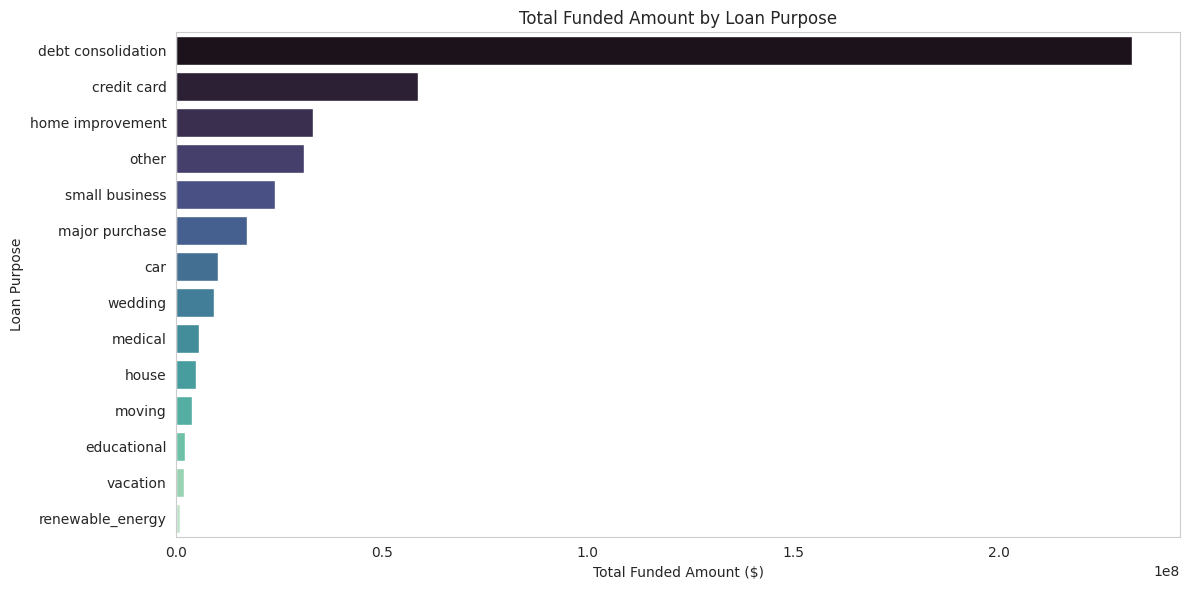

In [77]:
purpose_summary = df.groupby('purpose').agg(
    total_applications=('id', 'count'),
    total_funded=('loan_amount', 'sum')
).reset_index().sort_values('total_funded', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=purpose_summary, x='total_funded', y='purpose', hue='purpose', palette='mako')
plt.title('Total Funded Amount by Loan Purpose')
plt.xlabel('Total Funded Amount ($)')
plt.ylabel('Loan Purpose')
plt.grid(False)
plt.tight_layout()
plt.show()

**Insight:** `debt_consolidation` dominates the portfolio at roughly **$230M funded** — more than double the next category (`credit_card`, ~$58M) — and together these two purposes account for the large majority of total lending. This suggests the bank's core lending use case is helping borrowers restructure existing debt, which has different risk dynamics (e.g., DTI, repayment behavior) than, say, small business or medical loans.

## 6. Home Ownership Analysis (Tree Map)

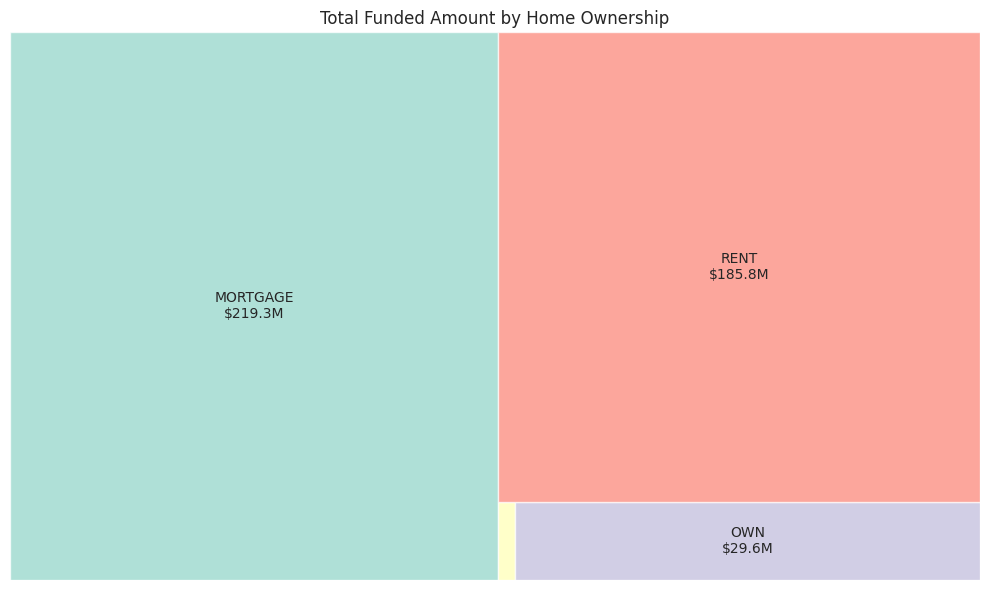

In [89]:
home_summary = df.groupby('home_ownership')['loan_amount'].sum().reset_index()


# ignoring label for very small category
threshold = 0.02 #labels for category more than 2%
total = home_summary['loan_amount'].sum()
home_summary['label'] = np.where( # using where condition to show label
    home_summary['loan_amount'] / total > threshold, # yes condition
    home_summary['home_ownership'] + '\n$' + (home_summary['loan_amount'] / 1e6).round(1).astype(str) + 'M', # if yes then print /n$ for showing dollar, rounf for converting into million
    '' #else empty
)

plt.figure(figsize= (10,6))
squarify.plot(sizes=home_summary['loan_amount'], label=home_summary['label'], alpha=0.7, color=sns.color_palette('Set3')) #alpha for transparency
plt.title('Total Funded Amount by Home Ownership')
plt.axis('off')
plt.tight_layout()
plt.show()

**Insight:** `MORTGAGE` ($219.3M) and `RENT` ($185.8M) borrowers account for the vast majority of funding, with `OWN` ($29.6M) a distant third and `OTHER` negligible. Renters representing over 40% of funded value is notable — renters typically have less collateral than homeowners, which is a relevant risk factor to weigh alongside DTI and grade when assessing this segment.

## 5. Key Findings & Recommendations

**Portfolio health**
- The portfolio is growing and collecting well: applications, funding, and repayments were all up double-digits month-over-month, with repayment growth outpacing funding growth.
- **13.8% of loans are Charged Off**, resulting in an estimated **$28.2M in unrecovered principal** — this is the clearest single risk metric in the portfolio and the natural target for any risk-reduction initiative.

**Portfolio composition**
- Lending is concentrated in `debt_consolidation` and `credit_card` purposes, 36-month terms, and `MORTGAGE`/`RENT` borrowers — a fairly conservative, familiar consumer-lending mix.
- Funded amount scales with employment length, consistent with standard underwriting logic.

**Recommendations**
1. Investigate whether Charged Off loans cluster in specific `grade`, `purpose`, or `home_ownership` segments (e.g., renters, lower grades) to target underwriting improvements where they'll have the most impact.
2. Monitor the recent uptick in average interest rate and DTI together — rising DTI alongside rising rates can compound repayment risk for borrowers already carrying more debt.
3. Given renters represent a large share of funded value with typically less collateral, consider whether current approval criteria adequately price for this segment's risk.

**Limitations:** this analysis is based on a single snapshot of loan records without external economic context (e.g., regional unemployment, rate environment) — findings should be validated against a live risk model before being used for underwriting decisions.